In [1]:
import torch
from botorch.utils.multi_objective.pareto import is_non_dominated

# --- 1. Load the Final Checkpoint ---
# Change this to your highest iteration checkpoint file
CHECKPOINT_FILE = "bo_checkpoint_iter_30.pt" 
checkpoint = torch.load(CHECKPOINT_FILE)

train_X = checkpoint['train_X']
train_Y = checkpoint['train_Y']


T_MIN = 0.05    
S_MAX = 320

c1_valid = train_Y[:, 2] >= T_MIN
c2_valid = train_Y[:, 3] <= S_MAX
is_feasible = c1_valid & c2_valid

feasible_X = train_X[is_feasible]
feasible_Y = train_Y[is_feasible]

if len(feasible_X) == 0:
    print("Optimization failed to find any physically feasible solutions.")
else:
    print(f"Found {len(feasible_X)} feasible evaluations. Calculating Pareto front...\n")
    
    # --- 3. Identify the Pareto Front ---
    # We extract just the objectives (0 and 1)
    # BoTorch's `is_non_dominated` assumes we want to MAXIMIZE all objectives.
    # Since Y[0] is -avg_stress, maximizing it correctly minimizes the real stress.
    objectives = feasible_Y[:, 0:2]
    pareto_mask = is_non_dominated(objectives)
    
    best_X = feasible_X[pareto_mask]
    best_Y = feasible_Y[pareto_mask]
    
    # --- 4. Output the Best Results ---
    print(f"=== {len(best_X)} PARETO OPTIMAL SOLUTIONS FOUND ===\n")
    
    for i in range(len(best_X)):
        # Revert the negative sign on average stress for readability
        true_avg_stress = -best_Y[i, 0].item()
        avg_ht = best_Y[i, 1].item()
        min_ht = best_Y[i, 2].item()
        max_stress = best_Y[i, 3].item()
        
        print(f"Solution {i+1}:")
        print(f"  Objectives  -> Avg Stress: {true_avg_stress:.2f} MPa | Avg HT: {avg_ht:.2f} s")
        print(f"  Constraints -> Max Stress: {max_stress:.2f} MPa | Min HT: {min_ht:.2f} s")
        print(f"  Parameters  -> {best_X[i].numpy().round(4)}\n")

/data/pxl1051/ded_dt_thermomechanical_solver/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Found 65 feasible evaluations. Calculating Pareto front...

=== 11 PARETO OPTIMAL SOLUTIONS FOUND ===

Solution 1:
  Objectives  -> Avg Stress: 271.28 MPa | Avg HT: 0.94 s
  Constraints -> Max Stress: 318.60 MPa | Min HT: 0.07 s
  Parameters  -> [0.3    0.5279 0.1466 0.6331 0.9204 0.857  0.7042 0.8014 0.2879 0.2484]

Solution 2:
  Objectives  -> Avg Stress: 271.06 MPa | Avg HT: 0.89 s
  Constraints -> Max Stress: 319.20 MPa | Min HT: 0.05 s
  Parameters  -> [0.1    0.3936 0.1903 0.3208 0.2535 0.2401 0.0594 0.1546 0.181  0.4675]

Solution 3:
  Objectives  -> Avg Stress: 270.92 MPa | Avg HT: 0.87 s
  Constraints -> Max Stress: 316.68 MPa | Min HT: 0.05 s
  Parameters  -> [0.5    0.8554 0.3627 0.4099 0.1337 0.2648 0.9421 0.78   0.7291 0.526 ]

Solution 4:
  Objectives  -> Avg Stress: 271.04 MPa | Avg HT: 0.87 s
  Constraints -> Max Stress: 317.99 MPa | Min HT: 0.07 s
  Parameters  -> [0.5    0.9743 0.9274 0.5856 0.1531 0.4956 0.2365 0.5536 0.9278 0.1921]

Solution 5:
  Objectives  -> Avg 

In [ ]:
import os
import zarr
import numpy as np
import pandas as pd
from tqdm import tqdm

def calculate_paper_ht(zarr_path, dt=0.02):
    """
    Calculates Heat Treatment time using the Bounding Box method from Eq 10
    of the Karkaria et al. paper.
    """
    try:
        z = zarr.open(zarr_path, mode='r')
        temp_history = z['temperature'][:] # Shape: (time_steps, nodes)
        
        # Define the temperature band (654 C to 857 C)
        in_band = (temp_history >= 927.15) & (temp_history <= 1130.15)
        
        # Boolean array: Did the node EVER reach the band?
        reached_band = np.any(in_band, axis=0)
        
        # Create an array of indices to find min(j) and max(j)
        time_indices = np.arange(temp_history.shape[0])[:, np.newaxis]
        
        # Find max(j): replace False with -1, then take max over time (axis 0)
        valid_max = np.where(in_band, time_indices, -1)
        last_idx = np.max(valid_max, axis=0)
        
        # Find min(j): replace False with infinity, then take min over time (axis 0)
        valid_min = np.where(in_band, time_indices, np.inf)
        first_idx = np.min(valid_min, axis=0)
        
        # Calculate durations: (max(j) - min(j)) * dt
        ht_durations = np.zeros(temp_history.shape[1])
        ht_durations[reached_band] = (last_idx[reached_band] - first_idx[reached_band]) * dt
        
        # 1. Strict Paper Objective: Average over ALL nodes in the simulation (N)
        paper_avg_ht = float(np.mean(ht_durations))
        
        # 2. Physics Check: Average ONLY over nodes that actually got hot 
        # (filters out the massive cold substrate)
        active_avg_ht = float(np.mean(ht_durations[reached_band])) if np.any(reached_band) else 0.0
        
        # 3. Your Original Cumulative Method (for direct comparison)
        cumulative_durations = np.sum(in_band * dt, axis=0)
        original_cumulative_ht = float(np.mean(cumulative_durations))
        
        return paper_avg_ht, active_avg_ht, original_cumulative_ht

    except Exception as e:
        return None, None, None

def main():
    results = []
    
    for i in tqdm(range(80), desc="Analyzing Zarr Files"):
        zarr_path = f"stress_history_eval_{i}.zarr"
        
        if os.path.exists(zarr_path):
            p_avg, a_avg, c_avg = calculate_paper_ht(zarr_path)
            
            if p_avg is not None:
                results.append({
                    "eval_id": i,
                    "paper_bounding_box_ht": p_avg,
                    "active_nodes_bounding_box_ht": a_avg,
                    "your_original_cumulative_ht": c_avg
                })

    if not results:
        print("No valid Zarr files found or successfully processed.")
        return

    df = pd.DataFrame(results)
    df.to_csv("ht_comparison_results.csv", index=False)
    
    print("\n" + "="*60)
    print("OBJECTIVE CALCULATION COMPARISON (Summary Stats)")
    print("="*60)
    print(df[["paper_bounding_box_ht", "active_nodes_bounding_box_ht", "your_original_cumulative_ht"]].describe())
    
    print("\n" + "="*60)
    print("ANALYSIS")
    print("="*60)
    print("1. 'your_original_cumulative_ht': This is what your BO was looking at (~0.22s).")
    print("2. 'paper_bounding_box_ht': This is exactly what the paper optimized.")
    print("3. 'active_nodes_bounding_box_ht': This shows what the paper's math looks like if you")
    print("   strip away the cold substrate. This number will be massively higher.")

if __name__ == "__main__":
    main()

Analyzing Zarr Files: 100%|██████████| 80/80 [02:38<00:00,  1.98s/it]


OBJECTIVE CALCULATION COMPARISON (Summary Stats)
       paper_bounding_box_ht  active_nodes_bounding_box_ht  \
count              80.000000                     80.000000   
mean                0.677880                      8.038162   
std                 0.037593                      0.711978   
min                 0.593957                      6.670417   
25%                 0.649063                      7.452881   
50%                 0.683013                      8.106653   
75%                 0.715068                      8.744830   
max                 0.747114                      9.295643   

       your_original_cumulative_ht  
count                    80.000000  
mean                      0.059742  
std                       0.002273  
min                       0.054871  
25%                       0.058066  
50%                       0.059447  
75%                       0.062013  
max                       0.062633  

ANALYSIS
1. 'your_original_cumulative_ht': This is what y

In [15]:
import zarr
import numpy as np

# Load the geometry to get node coordinates
# Assuming domain_mgr from thermomechanical.py is accessible, 
# or we can just load the nodes from the .k file manually.
# For now, we will just look at the raw Zarr indices.

def find_cold_nodes(zarr_path, dt=0.02):
    z = zarr.open(zarr_path, mode='r')
    temp_history = z['temperature'][:] 
    
    # 1. Identify the temperature band
    in_band = (temp_history >= 927.15) & (temp_history <= 1130.15)
    
    # 2. Calculate cumulative time in band for EVERY node
    cumulative_time = np.sum(in_band * dt, axis=0)
    
    # 3. We only care about deposited nodes (ignore the substrate)
    # Since we don't have the exact birth array here, we can infer deposited nodes
    # as any node that ever exceeded ambient (e.g., > 400K)
    was_deposited = np.max(temp_history, axis=0) > 400.0
    
    deposited_times = cumulative_time[was_deposited]
    
    # Find the failed nodes
    failed_nodes_mask = (cumulative_time == 0.0) & was_deposited
    failed_node_indices = np.where(failed_nodes_mask)[0]
    
    print(f"Total Deposited Nodes: {np.sum(was_deposited)}")
    print(f"Nodes with 0.0s Heat Treatment: {len(failed_node_indices)}")
    
    # Check max temperatures of the failed nodes
    if len(failed_node_indices) > 0:
        max_temps_of_failed = np.max(temp_history[:, failed_node_indices], axis=0)
        
        too_cold = np.sum(max_temps_of_failed < 927.15)
        too_fast = np.sum(max_temps_of_failed >= 927.15) # Exceeded temp but didn't stay long enough
        
        print(f"  -> {too_cold} nodes NEVER reached the minimum 654 C.")
        print(f"  -> {too_fast} nodes reached the temperature but cooled too fast to register a full dt step.")
        
        print(f"\nFirst 10 Failed Node Indices: {failed_node_indices[:10]}")

find_cold_nodes("stress_history_eval_70.zarr")

Total Deposited Nodes: 12138
Nodes with 0.0s Heat Treatment: 2900
  -> 2900 nodes NEVER reached the minimum 654 C.
  -> 0 nodes reached the temperature but cooled too fast to register a full dt step.

First 10 Failed Node Indices: [ 9 28 30 33 35 43 47 48 50 85]


In [1]:
import zarr
import numpy as np

def analyze_cooling(zarr_path, target_time=35.0):
    try:
        z = zarr.open(zarr_path, mode='r')
        times = z['time'][:]
        temps = z['temperature'][:]
        
        # Find the time index closest to 35 seconds (just after laser turns off)
        idx_35 = np.argmin(np.abs(times - target_time))
        actual_time_35 = times[idx_35]
        
        # Last time index (end of the cooling phase)
        idx_end = len(times) - 1
        actual_time_end = times[idx_end]
        
        print(f"--- Cooling Analysis for {zarr_path} ---")
        print(f"Snapshot 1 (Laser just off): t = {actual_time_35:.2f}s")
        print(f"Snapshot 2 (End of sim):     t = {actual_time_end:.2f}s")
        
        # We only care about nodes that actually got hot (deposited material)
        # 400K is a safe threshold to ignore the cold steel substrate
        deposited_mask = np.max(temps, axis=0) > 400.0
        
        temps_35 = temps[idx_35, deposited_mask]
        temps_end = temps[-1, deposited_mask]
        
        max_35, max_end = np.max(temps_35), np.max(temps_end)
        avg_35, avg_end = np.mean(temps_35), np.mean(temps_end)
        
        print(f"\nMax Temperature across the deposited wall:")
        print(f"  At {actual_time_35:.2f}s: {max_35:.2f} K")
        print(f"  At {actual_time_end:.2f}s: {max_end:.2f} K")
        print(f"  Total Drop:  {max_35 - max_end:.2f} K")
        
        print(f"\nAverage Temperature of the deposited wall:")
        print(f"  At {actual_time_35:.2f}s: {avg_35:.2f} K")
        print(f"  At {actual_time_end:.2f}s: {avg_end:.2f} K")
        print(f"  Total Drop:  {avg_35 - avg_end:.2f} K")
        
        # Check if the hottest part is still in the heat treatment band
        if max_end > 927.15:
            print(f"\n[WARNING] Your hottest nodes are STILL above 654 C at the end of the simulation!")
            print(f"          You need to increase the ENDTIM in your .k file to capture the full cooling time.")
        else:
            print(f"\n[OK] The wall successfully cooled below the 654 C threshold.")
            
    except Exception as e:
        print(f"Failed to read {zarr_path}: {e}")

# Point this at your existing eval 89 file
analyze_cooling("stress_history_eval_89.zarr", target_time=35.0)

--- Cooling Analysis for stress_history_eval_89.zarr ---
Snapshot 1 (Laser just off): t = 34.98s
Snapshot 2 (End of sim):     t = 84.08s

Max Temperature across the deposited wall:
  At 34.98s: 803.29 K
  At 84.08s: 300.00 K
  Total Drop:  503.29 K

Average Temperature of the deposited wall:
  At 34.98s: 654.22 K
  At 84.08s: 300.00 K
  Total Drop:  354.22 K

[OK] The wall successfully cooled below the 654 C threshold.


In [2]:
import zarr
import numpy as np

zarr_path = "stress_history_eval_89.zarr"

z = zarr.open(zarr_path, mode='r')
times = z['time'][:]
temps = z['temperature'][:]

# Filter for deposited nodes (ever reached > 400K)
deposited_mask = np.max(temps, axis=0) > 400.0
temps_deposited = temps[:, deposited_mask]

# Get the maximum temperature of the wall at every single time step
max_temps_over_time = np.max(temps_deposited, axis=1)

# Find the exact time step where the max temperature drops to 300.1 K
target_temp = 300.1
cooled_indices = np.where(max_temps_over_time <= target_temp)[0]

if len(cooled_indices) > 0:
    first_cooled_idx = cooled_indices[0]
    time_to_cool = times[first_cooled_idx]
    print(f"The entire wall returned to ambient temperature at: t = {time_to_cool:.2f} s")
    print(f"Total cooling phase duration: {time_to_cool - 34.1:.2f} s")
else:
    print(f"The wall never reached exactly {target_temp} K. Final temp was {max_temps_over_time[-1]:.2f} K")

The entire wall returned to ambient temperature at: t = 49.88 s
Total cooling phase duration: 15.78 s


In [3]:
import zarr
import numpy as np

zarr_path = "stress_history_eval_89.zarr"

z = zarr.open(zarr_path, mode='r')
times = z['time'][:]
temps = z['temperature'][:]

# Filter for deposited nodes (ever reached > 400K)
deposited_mask = np.max(temps, axis=0) > 400.0
temps_deposited = temps[:, deposited_mask]

# Get the maximum temperature of the wall at every single time step
max_temps_over_time = np.max(temps_deposited, axis=1)

# Find the exact time step where the max temperature drops to 300.1 K
target_temp = 300.1
cooled_indices = np.where(max_temps_over_time <= target_temp)[0]

if len(cooled_indices) > 0:
    first_cooled_idx = cooled_indices[0]
    time_to_cool = times[first_cooled_idx]
    print(f"The entire wall returned to ambient temperature at: t = {time_to_cool:.2f} s")
    print(f"Total cooling phase duration: {time_to_cool - 34.1:.2f} s")
else:
    print(f"The wall never reached exactly {target_temp} K. Final temp was {max_temps_over_time[-1]:.2f} K")

The entire wall returned to ambient temperature at: t = 49.88 s
Total cooling phase duration: 15.78 s


In [2]:
import zarr
import numpy as np

# Change this to your most recent successful simulation file
zarr_path = "stress_history_eval_60.zarr" 

try:
    z = zarr.open(zarr_path, mode='r')
    temps = z['temperature'][:]
    times = z['time'][:]
    
    # Find the absolute maximum temperature in the entire 2D array (Time x Nodes)
    global_max_temp = np.max(temps)
    
    # Find exactly WHEN and WHERE this peak occurred
    max_index = np.unravel_index(np.argmax(temps), temps.shape)
    time_step_idx = max_index[0]
    node_idx = max_index[1]
    
    time_of_max = times[time_step_idx]
    
    print(f"--- Peak Temperature Analysis for {zarr_path} ---")
    print(f"Absolute Maximum Temperature: {global_max_temp:.2f} K")
    print(f"  -> Reached at Simulation Time: {time_of_max:.2f} s")
    print(f"  -> Reached at Node ID: {node_idx}")
    
    print("-" * 40)
    if global_max_temp >= 1878.0:
        print(f"[PHYSICS OK]: Peak temperature exceeded the 1878 K Solidus.")
        print(f"              The laser successfully created a liquid melt pool.")
    else:
        print(f"[WARNING]: Peak temperature ({global_max_temp:.2f} K) is below 1878 K!")
        print(f"           The metal never melted. The print physically failed (Lack of Fusion).")
        
except Exception as e:
    print(f"Failed to read {zarr_path}: {e}")

--- Peak Temperature Analysis for stress_history_eval_60.zarr ---
Absolute Maximum Temperature: 3573.81 K
  -> Reached at Simulation Time: 25.66 s
  -> Reached at Node ID: 24842
----------------------------------------
[PHYSICS OK]: Peak temperature exceeded the 1878 K Solidus.
              The laser successfully created a liquid melt pool.


Loading data from bo_checkpoint_iter_50.pt...
Total Evaluations: 150
Feasible Designs: 123
Infeasible Designs: 27
Saved Pareto plot to 'pareto_front_report.png'
Saved Acquisition plot to 'acquisition_convergence.png'


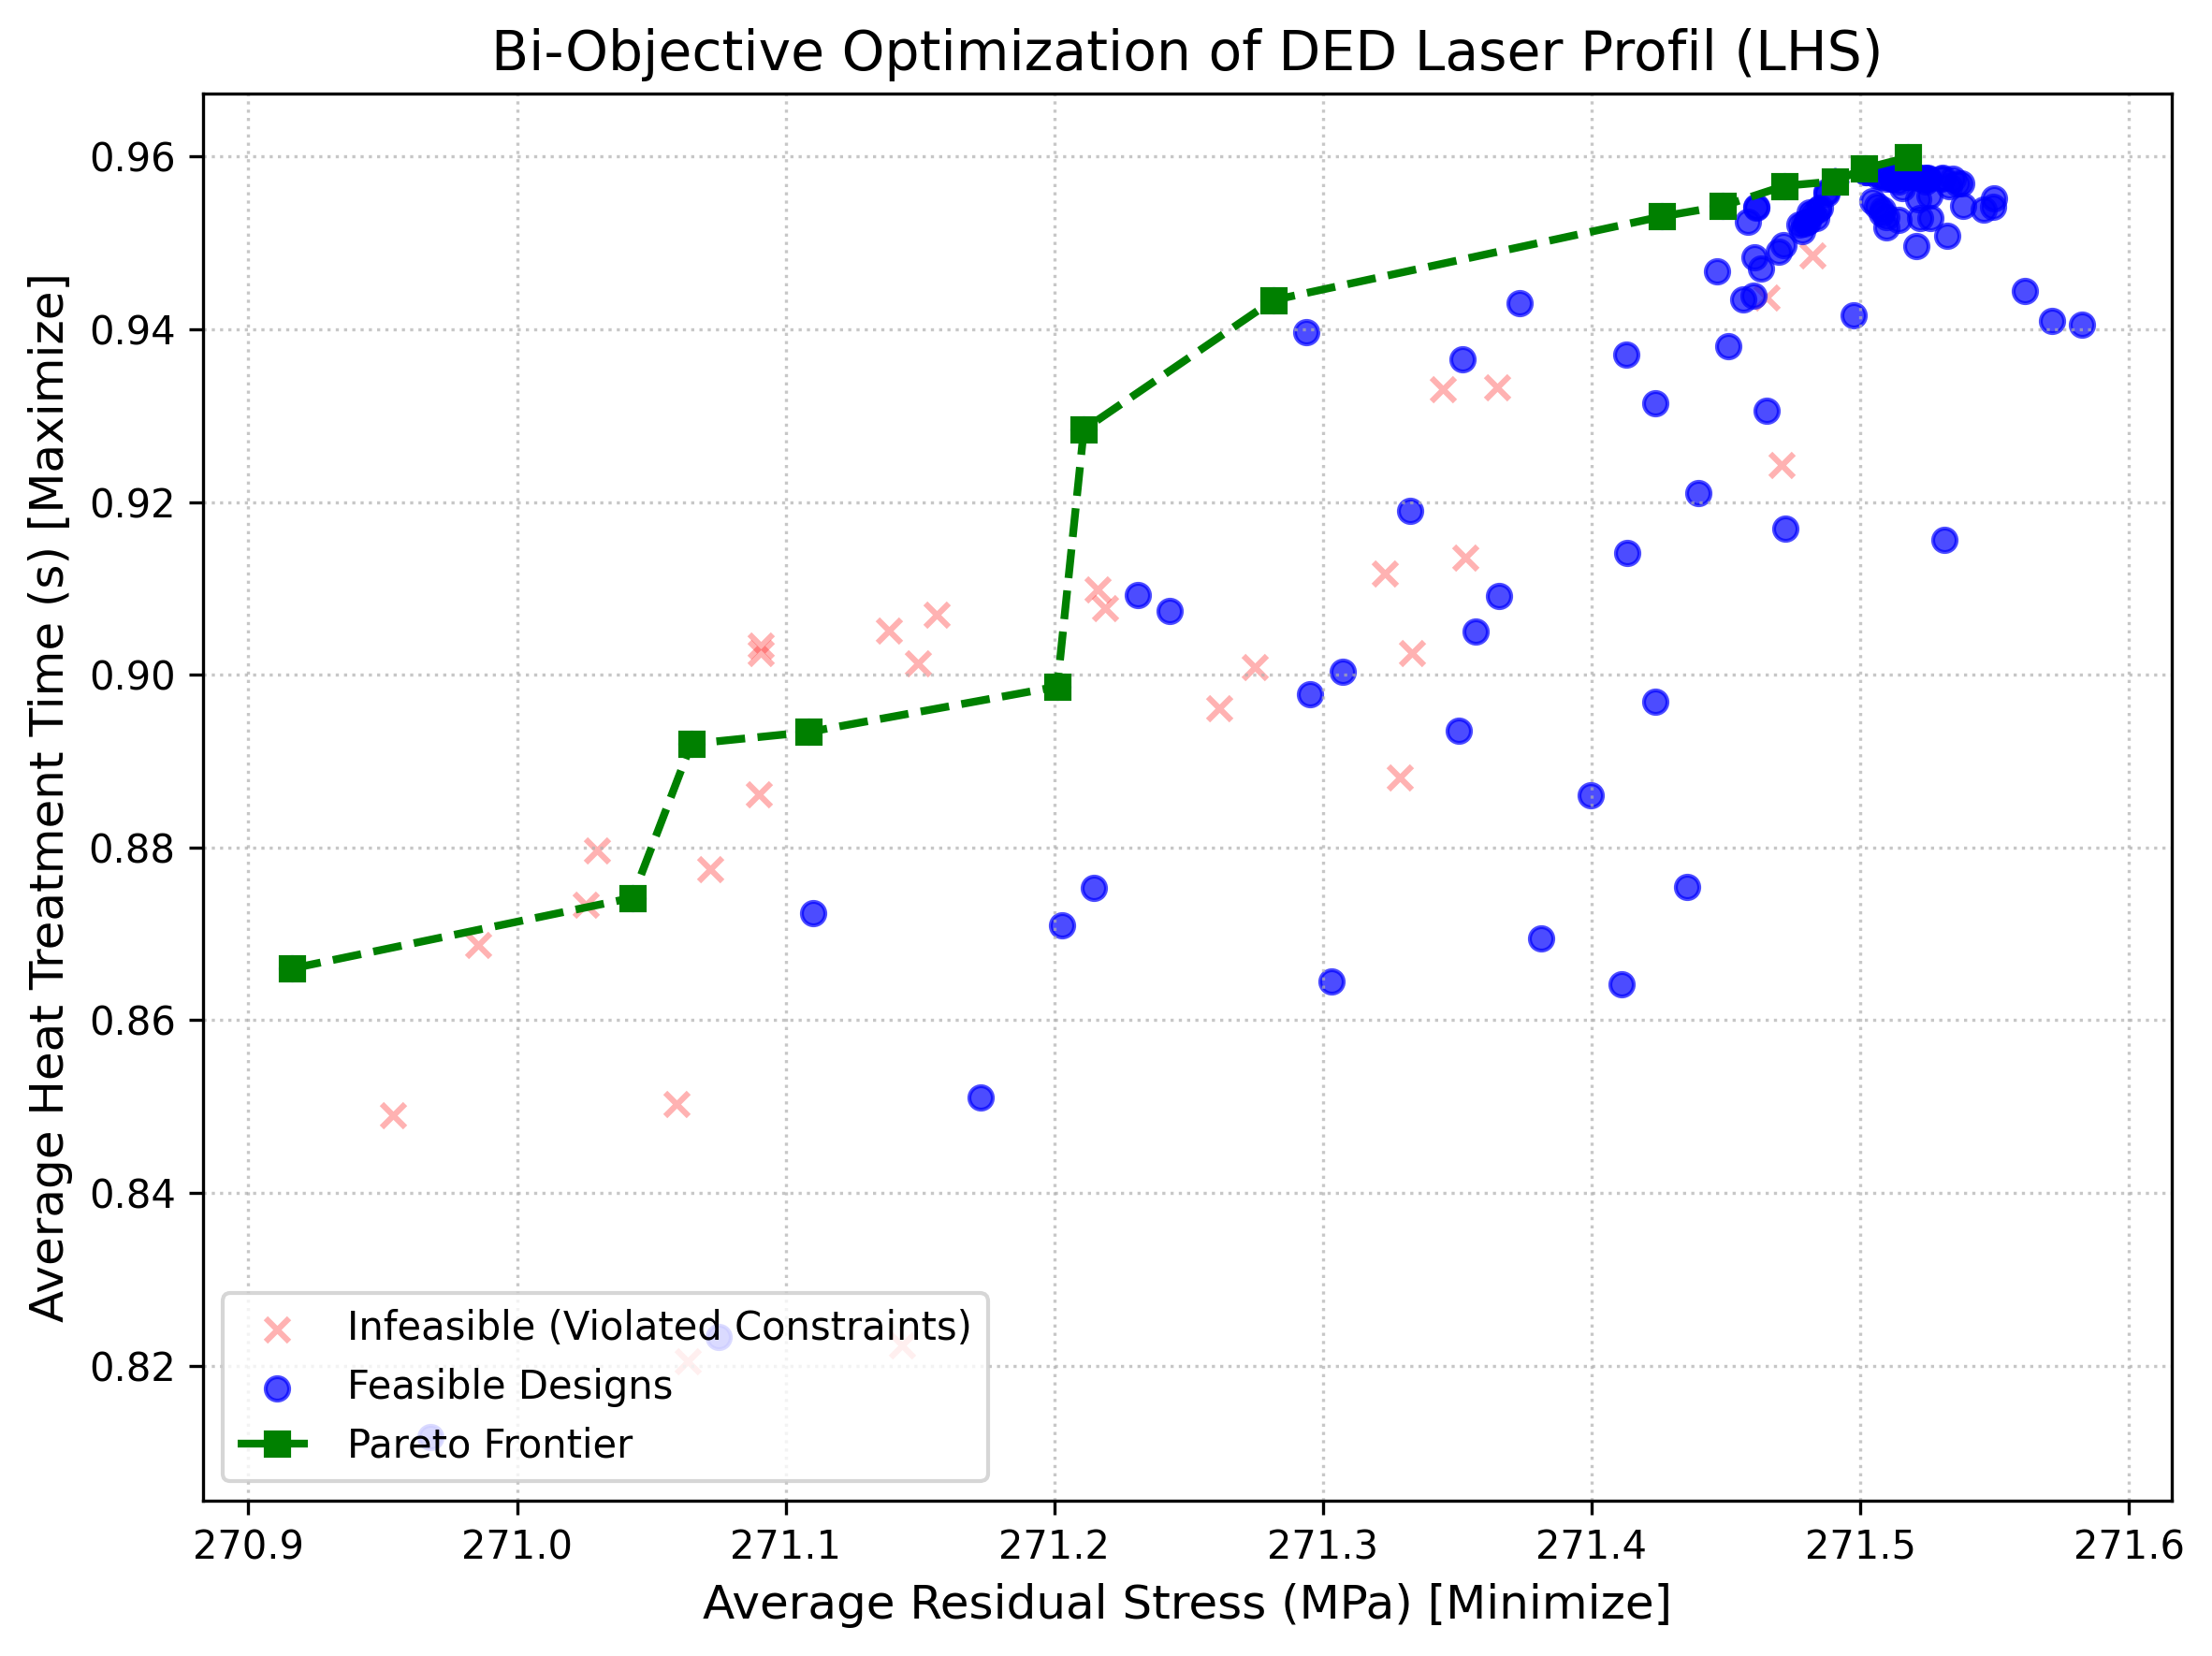

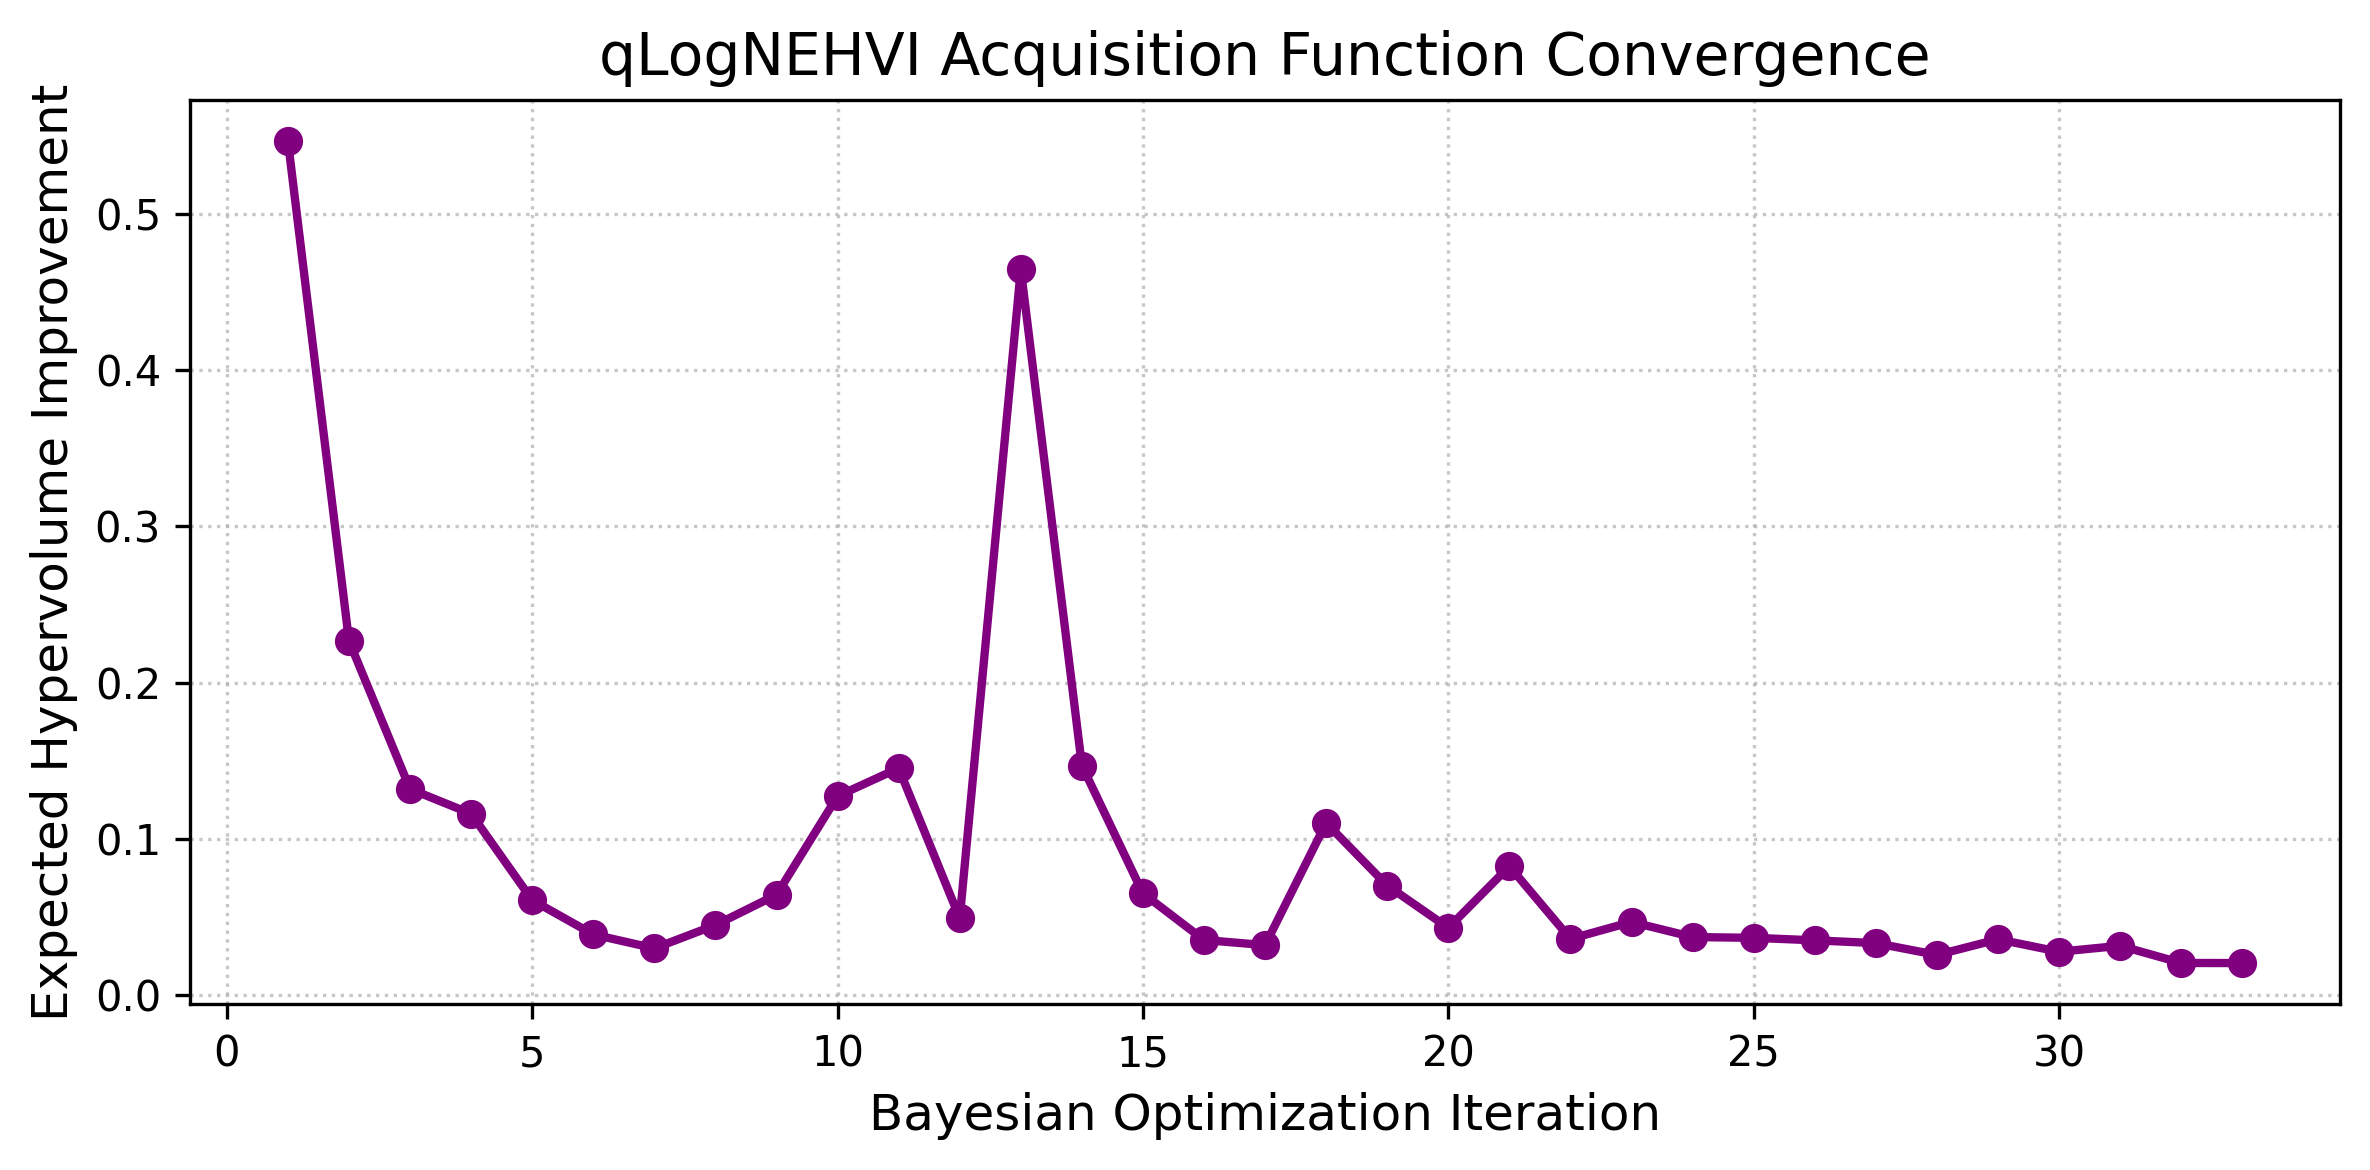

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt

def get_pareto_front(stress, ht_time):
    """
    Finds the Pareto front. 
    Objective: Minimize stress (X), Maximize HT time (Y).
    """
    points = np.column_stack((stress, ht_time))
    # Sort primarily by stress (ascending), then by HT time (descending)
    sorted_indices = np.lexsort((-points[:, 1], points[:, 0]))
    sorted_points = points[sorted_indices]

    pareto_front = []
    max_ht_so_far = -np.inf

    for pt in sorted_points:
        # Since stress is sorted ascending, we only add to the front 
        # if the HT time is strictly better than the best we've seen so far.
        if pt[1] > max_ht_so_far:
            pareto_front.append(pt)
            max_ht_so_far = pt[1]

    return np.array(pareto_front)

def generate_report_plots(checkpoint_file="bo_checkpoint_iter_0.pt"):
    print(f"Loading data from {checkpoint_file}...")
    checkpoint = torch.load(checkpoint_file, map_location=torch.device('cpu'))
    
    train_Y = checkpoint['train_Y']
    train_acq = checkpoint.get('train_acq_vals', torch.empty(0))
    
    print(f"Total Evaluations: {len(train_Y)}")
    
    # 1. Extract Objectives (Remember we stored -avg_stress, so we invert it back)
    avg_stress = -train_Y[:, 0].numpy()
    avg_ht = train_Y[:, 1].numpy()
    min_ht = train_Y[:, 2].numpy()
    max_stress = train_Y[:, 3].numpy()
    
    # 2. Filter by Constraints
    S_MAX = 320.0
    T_MIN = 0.05
    
    is_feasible = (max_stress <= S_MAX) & (min_ht >= T_MIN)
    feasible_idx = np.where(is_feasible)[0]
    infeasible_idx = np.where(~is_feasible)[0]
    
    print(f"Feasible Designs: {len(feasible_idx)}")
    print(f"Infeasible Designs: {len(infeasible_idx)}")
    
    # ==========================================
    # PLOT 1: PARETO FRONT
    # ==========================================
    plt.figure(figsize=(8, 6), dpi=300)
    
    # Plot Infeasible points (Red)
    plt.scatter(avg_stress[infeasible_idx], avg_ht[infeasible_idx], 
                c='red', alpha=0.3, label='Infeasible (Violated Constraints)', marker='x')
    
    # Plot Feasible points (Blue)
    if len(feasible_idx) > 0:
        plt.scatter(avg_stress[feasible_idx], avg_ht[feasible_idx], 
                    c='blue', alpha=0.7, label='Feasible Designs', marker='o')
        
        # Calculate and plot the actual Pareto front
        pareto_points = get_pareto_front(avg_stress[feasible_idx], avg_ht[feasible_idx])
        plt.plot(pareto_points[:, 0], pareto_points[:, 1], 
                 c='green', linewidth=2, linestyle='--', marker='s', label='Pareto Frontier')
    
    plt.title("Bi-Objective Optimization of DED Laser Profil (LHS)", fontsize=14)
    plt.xlabel("Average Residual Stress (MPa) [Minimize]", fontsize=12)
    plt.ylabel("Average Heat Treatment Time (s) [Maximize]", fontsize=12)
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.legend(loc='lower left')
    plt.tight_layout()
    plt.savefig("pareto_front_report.png")
    print("Saved Pareto plot to 'pareto_front_report.png'")

    # ==========================================
    # PLOT 2: ACQUISITION CONVERGENCE
    # ==========================================
    
    if len(train_acq) > 0:
        plt.figure(figsize=(8, 4), dpi=300)
        iterations = np.arange(1, len(train_acq) + 1)
        
        plt.plot(iterations, np.exp(train_acq.detach().numpy()), marker='o', c='purple', linewidth=2)
        plt.title("qLogNEHVI Acquisition Function Convergence", fontsize=14)
        plt.xlabel("Bayesian Optimization Iteration", fontsize=12)
        plt.ylabel("Expected Hypervolume Improvement", fontsize=12)
        plt.grid(True, linestyle=':', alpha=0.7)
        
        plt.tight_layout()
        plt.savefig("acquisition_convergence.png")
        print("Saved Acquisition plot to 'acquisition_convergence.png'")
    else:
        print("No acquisition values found to plot (likely only initial data was evaluated).")

if __name__ == "__main__":
    # Point this to whatever your final checkpoint file is named
    generate_report_plots("bo_checkpoint_iter_50.pt")

 GENERATING SPATIAL FAILURE HEATMAP
Loading domain geometry...
Scanning 90 simulations for 0.0s Heat Treatment nodes...
Successfully processed 90 simulations.
Saved visualization to 'spatial_failure_heatmap.png'.


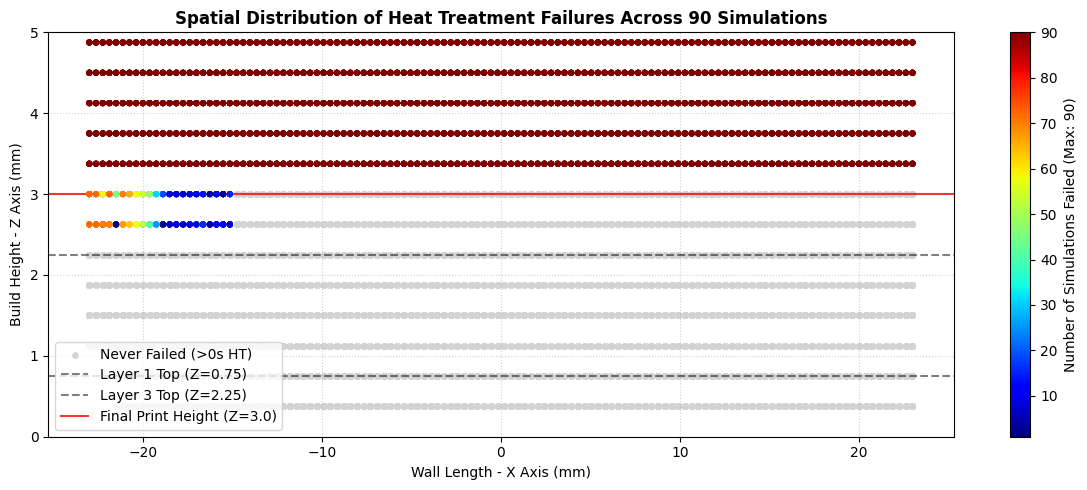

In [3]:
import zarr
import numpy as np
import matplotlib.pyplot as plt
import glob
import os
from gamma.simulator.gamma import domain_mgr

def plot_failure_heatmap(zarr_dir=".", geom_file="wall.k", input_dir="."):
    print(f"{'='*60}")
    print(f" GENERATING SPATIAL FAILURE HEATMAP")
    print(f"{'='*60}")

    # 1. Load Geometry
    print("Loading domain geometry...")
    domain = domain_mgr(filename=geom_file, input_data_dir=input_dir, verbose=False)
    nodes_array = domain.nodes.get() if hasattr(domain.nodes, 'get') else np.array(domain.nodes)
    node_birth = domain.node_birth.get() if hasattr(domain.node_birth, 'get') else np.array(domain.node_birth)

    # 2. Isolate Deposited Nodes
    # We only care about the printed wall (t >= 1e-5), ignoring the substrate block entirely.
    printed_mask = node_birth >= 1e-5
    printed_indices = np.where(printed_mask)[0]
    
    printed_nodes = nodes_array[printed_indices]
    
    # Array to track how many times each printed node failed across all simulations
    failure_counts = np.zeros(len(printed_indices), dtype=int)

    # 3. Analyze All Zarr Files
    zarr_files = sorted(glob.glob(os.path.join(zarr_dir, "stress_history_eval_*.zarr")))
    if not zarr_files:
        print("No .zarr files found!")
        return
        
    valid_sims = 0
    print(f"Scanning {len(zarr_files)} simulations for 0.0s Heat Treatment nodes...")

    for z_path in zarr_files:
        try:
            z = zarr.open(z_path, mode='r')
            temp_history = z['temperature'][:] 
            time_history = z['time'][:] 
            
            valid_steps = time_history > 1e-6
            if np.sum(valid_steps) == 0:
                continue
            last_valid_idx = np.where(valid_steps)[0][-1]
            
            # Slice arrays to valid length
            temp_history = temp_history[:last_valid_idx + 1]
            time_history = time_history[:last_valid_idx + 1]

            # Calculate dt
            dt_array = np.zeros_like(time_history)
            dt_array[1:] = time_history[1:] - time_history[:-1]
            dt_array_2d = dt_array[:, np.newaxis]

            # Calculate Time in Band
            in_band = (temp_history >= 927.15) & (temp_history <= 1130.15)
            cumulative_time = np.sum(in_band * dt_array_2d, axis=0)

            # Check printed nodes for 0.0s HT (< 1e-6)
            printed_ht = cumulative_time[printed_indices]
            failed_in_this_sim = printed_ht < 1e-6
            
            # Increment the failure count for nodes that failed in this specific simulation
            failure_counts += failed_in_this_sim.astype(int)
            valid_sims += 1
            
        except Exception as e:
            pass

    print(f"Successfully processed {valid_sims} simulations.")

    # 4. Generate the Plot
    plt.figure(figsize=(12, 5))
    plt.ylim(0,5)
    # Extract X and Z coordinates of the printed nodes (assuming wall is on Y=0 plane)
    X = printed_nodes[:, 0]
    Z = printed_nodes[:, 2]

    # Plot the background (nodes that never failed) in light gray
    perfect_mask = failure_counts == 0
    plt.scatter(X[perfect_mask], Z[perfect_mask], c='lightgray', s=15, label='Never Failed (>0s HT)')

    # Plot the failing nodes, colored by how frequently they failed
    failing_mask = failure_counts > 0
    if np.any(failing_mask):
        scatter = plt.scatter(
            X[failing_mask], Z[failing_mask], 
            c=failure_counts[failing_mask], 
            cmap='jet', # Blue is low failure rate, Red is 100% failure rate
            s=20, 
            edgecolor='none',
            zorder=3
        )
        cbar = plt.colorbar(scatter)
        cbar.set_label(f'Number of Simulations Failed (Max: {valid_sims})')

    # Draw geometric reference lines based on your toolpath
    plt.axhline(y=0.75, color='black', linestyle='--', alpha=0.5, label='Layer 1 Top (Z=0.75)')
    plt.axhline(y=2.25, color='black', linestyle='--', alpha=0.5, label='Layer 3 Top (Z=2.25)')
    plt.axhline(y=3.00, color='red', linestyle='-', alpha=0.8, label='Final Print Height (Z=3.0)')

    plt.title(f"Spatial Distribution of Heat Treatment Failures Across {valid_sims} Simulations", weight='bold')
    plt.xlabel("Wall Length - X Axis (mm)")
    plt.ylabel("Build Height - Z Axis (mm)")
    plt.legend(loc='lower left')
    plt.grid(True, linestyle=':', alpha=0.6)
    
    plt.tight_layout()
    plt.savefig("spatial_failure_heatmap.png", dpi=300)
    print("Saved visualization to 'spatial_failure_heatmap.png'.")

if __name__ == '__main__':
    plot_failure_heatmap()

In [4]:
import torch

# Replace with your actual checkpoint file name
checkpoint_file = "bo_checkpoint_iter_31.pt" # Assuming 14 evals means maybe iter 4 or 5
checkpoint = torch.load(checkpoint_file, map_location=torch.device('cpu'))

train_Y = checkpoint['train_Y']

# Remember: Index 0 is -avg_stress, Index 3 is max_stress
avg_stress = -train_Y[:, 0]
max_stress = train_Y[:, 3]

# Find the minimums
min_avg_stress = torch.min(avg_stress).item()
best_avg_idx = torch.argmin(avg_stress).item()

min_max_stress = torch.min(max_stress).item()
best_max_idx = torch.argmin(max_stress).item()

print(f"Total evaluations loaded: {len(train_Y)}")
print(f"---")
print(avg_stress, max_stress)
print(f"Lowest Average Residual Stress: {min_avg_stress:.2f} MPa (Found in Eval {best_avg_idx})")
print(f"Lowest Maximum Residual Stress: {min_max_stress:.2f} MPa (Found in Eval {best_max_idx})")

Total evaluations loaded: 93
---
tensor([271.3568, 271.3232, 271.2161, 271.3331, 270.9677, 271.2311, 271.2815,
        271.3447, 271.3506, 271.3072, 271.4133, 271.2747, 271.0595, 271.1101,
        271.3032, 271.0649, 271.0909, 271.0637, 271.3812, 271.3998, 271.0751,
        271.1563, 271.2429, 271.3655, 271.0296, 271.5314, 270.9164, 271.0429,
        271.2191, 271.3521, 271.1725, 271.2030, 271.2146, 271.0256, 271.2110,
        271.3284, 271.0720, 271.2951, 271.4127, 271.1493, 271.2615, 271.2011,
        271.3530, 271.4357, 270.9537, 271.1384, 271.1432, 271.1084, 271.5826,
        271.4110, 271.0907, 271.4583, 271.4603, 271.4632, 271.3731, 271.4236,
        271.5097, 271.4977, 271.4564, 271.4606, 271.5222, 271.5097, 271.5261,
        271.4262, 271.5383, 271.5322, 271.4466, 271.4784, 271.5141, 271.4613,
        271.5081, 270.9855, 271.4837, 271.4804, 271.4486, 271.4774, 271.4236,
        271.4615, 271.5712, 271.4696, 271.5044, 271.4874, 271.4653, 271.4718,
        271.3648, 271.4792, 271

In [14]:
import zarr
import numpy as np
import os

# Change this to match the exact name of one of your generated folders
ZARR_PATH = "stress_history_eval_0.zarr" 

def inspect_zarr(zarr_path):
    if not os.path.exists(zarr_path):
        print(f"[!] FAILED: The directory '{zarr_path}' does not exist.")
        print("    -> Conclusion: The code crashed BEFORE or DURING the Zarr initialization.")
        return

    try:
        root = zarr.open(zarr_path, mode='r')
        
        # Extract shapes and data
        time_arr = root['time'][:]
        temp_arr = root['temperature'][:]
        stress_arr = root['stress'][:]
        
        num_steps = len(time_arr)
        
        print(f"--- ZARR DIAGNOSTICS FOR: {zarr_path} ---")
        print(f"Total Saved Time Steps: {num_steps}")
        
        if num_steps == 0:
            print("[!] The arrays are empty. The simulation crashed immediately after starting.")
            return
            
        print(f"Final Simulated Time:   {time_arr[-1]:.3f} seconds")
        
        max_temp = np.max(temp_arr)
        print(f"Max Global Temperature: {max_temp:.2f} K")
        
        max_stress_component = np.max(np.abs(stress_arr))
        print(f"Max Absolute Stress:    {max_stress_component:.2f} MPa")
        
        # Diagnosis
        if time_arr[-1] < 27.0:
            print("\n[!] DIAGNOSIS: PHYSICS CRASH")
            print("    The simulation did not finish the 27.5s print. The solver or laser generator failed mid-run.")
        else:
            print("\n[+] DIAGNOSIS: OBJECTIVE EXTRACTION CRASH")
            print("    The physics simulation finished successfully! The error is isolated to the objective calculation block at the very end of the run.")
            
    except KeyError as e:
        print(f"[!] FAILED: Missing expected array in Zarr file: {e}")
        print("    Check the exact names of the arrays you used when initializing the Zarr store.")
    except Exception as e:
        print(f"[!] FAILED to read Zarr file: {e}")

if __name__ == "__main__":
    inspect_zarr(ZARR_PATH)

--- ZARR DIAGNOSTICS FOR: stress_history_eval_0.zarr ---
Total Saved Time Steps: 1843
Final Simulated Time:   42.996 seconds
Max Global Temperature: 3086.58 K
Max Absolute Stress:    1156.45 MPa

[+] DIAGNOSIS: OBJECTIVE EXTRACTION CRASH
    The physics simulation finished successfully! The error is isolated to the objective calculation block at the very end of the run.


In [5]:
import numpy as np
import cupy as cp
import matplotlib.pyplot as plt

# Import the parser directly from your custom module
from gamma.simulator.gamma import domain_mgr

# Set these to match the relative paths from your notebook's location
INPUT_DIR = "."  # or "../0_properties"
GEOM_FILE = "wall.k"

print("Parsing mesh and extracting timeline...")
# Initialize the domain manager just like the simulator does
domain = domain_mgr(filename=GEOM_FILE, input_data_dir=INPUT_DIR, verbose=True)

# Extract birth times. Safely move to CPU/NumPy in case domain_mgr uses CuPy under the hood.
if isinstance(domain.element_birth, cp.ndarray):
    birth_times = domain.element_birth.get()
else:
    birth_times = np.array(domain.element_birth)

# Filter out the substrate (elements born at t=0 or negative times)
printed_elements = birth_times[birth_times > 1e-5]

print("-" * 40)
print(f"Total elements in mesh: {len(birth_times)}")
print(f"Elements deposited by laser: {len(printed_elements)}")

if len(printed_elements) > 0:
    first_elem = np.min(printed_elements)
    last_elem = np.max(printed_elements)
    print(f"First deposition starts at: {first_elem:.4f} seconds")
    print(f"Final element born at:      {last_elem:.4f} seconds")
    print("-" * 40)
    
    if 27.53 < last_elem:
        print(f"⚠️ DANGER: Your SIM_DURATION (27.53s) cuts off {last_elem - 27.53:.2f}s early.")
else:
    print("No deposited elements found. Check if the .k file defines birth times correctly.")

Parsing mesh and extracting timeline...
Time of reading input files: 1.1460130214691162
Time of calculating critical timestep: 0.18544650077819824
Time of reading and interpolating toolpath: 0.0072612762451171875
Number of nodes: 96874
Number of elements: 83270
Number of time-steps: 21500
Time of generating surface: 2.767864227294922
----------------------------------------
Total elements in mesh: 83270
Elements deposited by laser: 68826
First deposition starts at: 0.0179 seconds
Final element born at:      280.8036 seconds
----------------------------------------
⚠️ DANGER: Your SIM_DURATION (27.53s) cuts off 253.27s early.


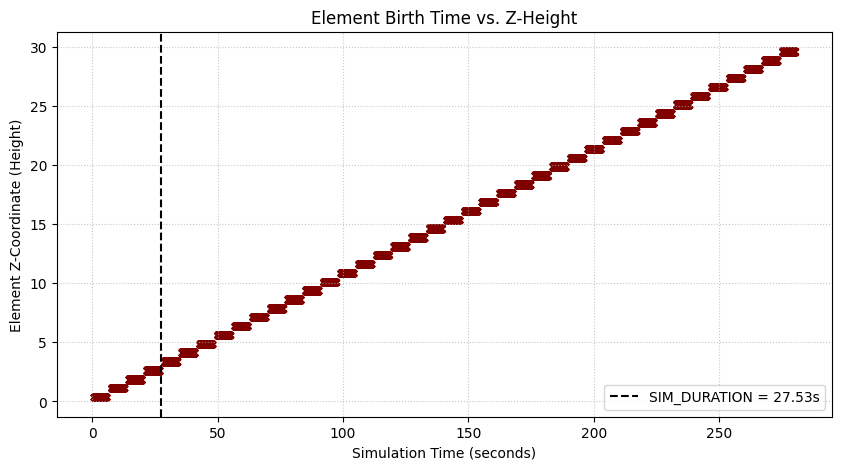

In [7]:
# Extract Z-coordinates of the element centers
if isinstance(domain.elements, cp.ndarray):
    elements_cpu = domain.elements.get()
    nodes_cpu = domain.nodes.get()
else:
    elements_cpu = np.array(domain.elements)
    nodes_cpu = np.array(domain.nodes.get() if hasattr(domain.nodes, 'get') else domain.nodes)

# Calculate the Z-center for each element
elem_z_centers = np.mean(nodes_cpu[elements_cpu, 2], axis=1)

# Mask for only the printed elements
mask = birth_times > 1e-5

plt.figure(figsize=(10, 5), dpi=100)
plt.scatter(birth_times[mask], elem_z_centers[mask], s=2, alpha=0.5, c='maroon')
plt.axvline(x=27.53, color='black', linestyle='--', label='SIM_DURATION = 27.53s')

plt.title("Element Birth Time vs. Z-Height")
plt.xlabel("Simulation Time (seconds)")
plt.ylabel("Element Z-Coordinate (Height)")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

In [1]:
import torch
import warnings
from botorch.models import SingleTaskGP, KroneckerMultiTaskGP
from botorch.models.transforms.outcome import Standardize
from botorch.models.transforms.input import Normalize
from botorch.fit import fit_gpytorch_mll
from gpytorch.mlls import ExactMarginalLogLikelihood
from botorch.exceptions.warnings import InputDataWarning

warnings.filterwarnings("ignore", category=InputDataWarning)

# 1. Load the initial LHS dataset you generated
# Assuming shape: X is [51, 10], Y is [51, 6] (where 0 is Avg Stress, 3 is Max Stress)
checkpoint = torch.load("bo_checkpoint_iter_0.pt")
train_X_full = checkpoint['train_X']
train_Y_full = checkpoint['train_Y']

# Isolate the mechanical objectives for the test
# Indices: 0 = -Avg Stress, 3 = Max Stress
Y_thermal = train_Y_full[..., 1:3]
Y_mech = train_Y_full[..., [0, 3]]
NUM_SAMPLES = train_X_full.shape[0]
NUM_PARAMS = train_X_full.shape[1]

print(f"Loaded {NUM_SAMPLES} samples. Running LOOCV...")

# Storage for NLPD scores
nlpd_single_task = []
nlpd_multi_task = []

for holdout_idx in range(NUM_SAMPLES):
    # --- A. SPLIT DATA (Leave One Out) ---
    train_mask = torch.ones(NUM_SAMPLES, dtype=torch.bool)
    train_mask[holdout_idx] = False
    
    X_train_cv = train_X_full[train_mask]
    Y_train_cv = Y_thermal[train_mask]
    
    X_test_cv = train_X_full[holdout_idx].unsqueeze(0)
    Y_test_cv = Y_thermal[holdout_idx].unsqueeze(0)
    
    # --- B. TRAIN INDEPENDENT GP (SingleTaskGP Batched) ---
    model_st = SingleTaskGP(
        X_train_cv, Y_train_cv,
        input_transform=Normalize(d=NUM_PARAMS),
        outcome_transform=Standardize(m=2)
    )
    mll_st = ExactMarginalLogLikelihood(model_st.likelihood, model_st)
    
    try:
        fit_gpytorch_mll(mll_st)
        
        # Predict the holdout point
        posterior_st = model_st.posterior(X_test_cv)
        mean_st = posterior_st.mean
        variance_st = posterior_st.variance
        
        # Calculate NLPD: -log_prob of the true value under the predicted Normal distribution
        dist_st = torch.distributions.Normal(mean_st, variance_st.sqrt())
        # Sum across both outputs for total score
        nlpd_st_val = -dist_st.log_prob(Y_test_cv).sum().item()
        nlpd_single_task.append(nlpd_st_val)
        
    except Exception as e:
        print(f"SingleTaskGP failed at index {holdout_idx}: {e}")

    # --- C. TRAIN JOINT GP (KroneckerMultiTaskGP) ---
    model_mt = KroneckerMultiTaskGP(
        X_train_cv, Y_train_cv,
        input_transform=Normalize(d=NUM_PARAMS),
        outcome_transform=Standardize(m=2)
    )
    mll_mt = ExactMarginalLogLikelihood(model_mt.likelihood, model_mt)
    
    try:
        fit_gpytorch_mll(mll_mt)
        
        # Predict the holdout point
        posterior_mt = model_mt.posterior(X_test_cv)
        mean_mt = posterior_mt.mean
        variance_mt = posterior_mt.variance
        
        dist_mt = torch.distributions.Normal(mean_mt, variance_mt.sqrt())
        nlpd_mt_val = -dist_mt.log_prob(Y_test_cv).sum().item()
        nlpd_multi_task.append(nlpd_mt_val)
        
    except Exception as e:
        print(f"MultiTaskGP failed at index {holdout_idx}: {e}")

# --- D. EVALUATE RESULTS ---
avg_nlpd_st = sum(nlpd_single_task) / len(nlpd_single_task)
avg_nlpd_mt = sum(nlpd_multi_task) / len(nlpd_multi_task)

print("\n" + "="*40)
print("LOOCV RESULTS (Lower is better)")
print("="*40)
print(f"Independent SingleTaskGPs NLPD : {avg_nlpd_st:.4f}")
print(f"Correlated MultiTaskGP NLPD    : {avg_nlpd_mt:.4f}")

if avg_nlpd_mt < avg_nlpd_st:
    print("\nCONCLUSION: The MultiTaskGP successfully exploits the physical correlation.")
    print("Action: Implement KroneckerMultiTaskGP in your BO script for the mechanical objectives.")
else:
    print("\nCONCLUSION: Negative Transfer detected. The linear correlation assumption fails on this dataset.")
    print("Action: Keep the independent SingleTaskGPs to protect the surrogate model.")

/data/pxl1051/ded_dt_thermomechanical_solver/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded 51 samples. Running LOOCV...

LOOCV RESULTS (Lower is better)
Independent SingleTaskGPs NLPD : -5.1731
Correlated MultiTaskGP NLPD    : -5.8498

CONCLUSION: The MultiTaskGP successfully exploits the physical correlation.
Action: Implement KroneckerMultiTaskGP in your BO script for the mechanical objectives.


In [ ]:
import torch
import warnings
from botorch.models import KroneckerMultiTaskGP
from botorch.models.transforms.outcome import Standardize
from botorch.models.transforms.input import Normalize
from botorch.fit import fit_gpytorch_mll
from gpytorch.mlls import ExactMarginalLogLikelihood
from gpytorch.kernels import RBFKernel, MaternKernel, ScaleKernel
from botorch.exceptions.warnings import InputDataWarning

warnings.filterwarnings("ignore", category=InputDataWarning)

# 1. Load the data (assuming train_X_full and Y_mech are already defined from previous block)
NUM_SAMPLES = train_X_full.shape[0]
NUM_PARAMS = train_X_full.shape[1]

print(f"Testing Kernels via LOOCV on {NUM_SAMPLES} samples...")

# Define the kernels to test. 
# ard_num_dims=NUM_PARAMS is CRITICAL: it gives each input (laser power, speed, etc.) its own lengthscale.
kernel_dict = {
    "RBF (Infinitely Smooth)": RBFKernel(ard_num_dims=NUM_PARAMS),
    "Matern 5/2 (BoTorch Default)": MaternKernel(nu=2.5, ard_num_dims=NUM_PARAMS),
    "Matern 3/2 (Rough/Jagged)": MaternKernel(nu=1.5, ard_num_dims=NUM_PARAMS)
}

results = {name: [] for name in kernel_dict.keys()}

for holdout_idx in range(NUM_SAMPLES):
    train_mask = torch.ones(NUM_SAMPLES, dtype=torch.bool)
    train_mask[holdout_idx] = False
    
    X_train_cv = train_X_full[train_mask]
    Y_train_cv = Y_thermal[train_mask]
    
    X_test_cv = train_X_full[holdout_idx].unsqueeze(0)
    Y_test_cv = Y_thermal[holdout_idx].unsqueeze(0)
    
    for kernel_name, base_kernel in kernel_dict.items():
        # Wrap the base kernel in a ScaleKernel to model the output variance
        covar_module = ScaleKernel(base_kernel)
        
        model = KroneckerMultiTaskGP(
            X_train_cv, Y_train_cv,
            data_covar_module=covar_module,
            input_transform=Normalize(d=NUM_PARAMS),
            outcome_transform=Standardize(m=2)
        )
        mll = ExactMarginalLogLikelihood(model.likelihood, model)
        
        try:
            fit_gpytorch_mll(mll)
            
            posterior = model.posterior(X_test_cv)
            dist = torch.distributions.Normal(posterior.mean, posterior.variance.sqrt())
            nlpd_val = -dist.log_prob(Y_test_cv).sum().item()
            
            results[kernel_name].append(nlpd_val)
            
        except Exception as e:
            # If a kernel causes Cholesky failure, penalize it heavily
            results[kernel_name].append(999.0)

# --- EVALUATE RESULTS ---
print("\n" + "="*50)
print("KERNEL LOOCV RESULTS (Lower NLPD is better)")
print("="*50)

best_kernel = None
best_score = float('inf')

for name, scores in results.items():
    avg_nlpd = sum(scores) / len(scores)
    print(f"{name:<30}: {avg_nlpd:.4f}")
    
    if avg_nlpd < best_score:
        best_score = avg_nlpd
        best_kernel = name

print("\n" + "-"*50)
print(f"WINNER: {best_kernel}")
print("-"*50)

Testing Kernels via LOOCV on 150 samples...


/data/pxl1051/ded_dt_thermomechanical_solver/.venv/lib/python3.14/site-packages/botorch/fit.py:214: OptimizationWarning: `scipy_minimize` terminated with status OptimizationStatus.FAILURE, displaying original message from `scipy.optimize.minimize`: ABNORMAL: 
  result = optimizer(mll, closure=closure, **optimizer_kwargs)
/data/pxl1051/ded_dt_thermomechanical_solver/.venv/lib/python3.14/site-packages/botorch/fit.py:214: OptimizationWarning: `scipy_minimize` terminated with status OptimizationStatus.FAILURE, displaying original message from `scipy.optimize.minimize`: ABNORMAL: 
  result = optimizer(mll, closure=closure, **optimizer_kwargs)
/data/pxl1051/ded_dt_thermomechanical_solver/.venv/lib/python3.14/site-packages/botorch/fit.py:214: OptimizationWarning: `scipy_minimize` terminated with status OptimizationStatus.FAILURE, displaying original message from `scipy.optimize.minimize`: ABNORMAL: 
  result = optimizer(mll, closure=closure, **optimizer_kwargs)
/data/pxl1051/ded_dt_thermomech


KERNEL LOOCV RESULTS (Lower NLPD is better)
RBF (Infinitely Smooth)       : 3.6960
Matern 5/2 (BoTorch Default)  : 31.2436
Matern 3/2 (Rough/Jagged)     : 18.3243

--------------------------------------------------
WINNER: RBF (Infinitely Smooth)
--------------------------------------------------


In [3]:
from scipy.stats import wilcoxon

print("\n" + "="*50)
print("STATISTICAL SIGNIFICANCE (Wilcoxon Signed-Rank)")
print("="*50)

# Let's compare the default (Matern 5/2) against the winner (assuming it's not the default)
default_kernel = "Matern 5/2 (BoTorch Default)"
winner_kernel = best_kernel

if default_kernel == winner_kernel:
    print(f"The BoTorch default ({default_kernel}) won the average. Checking if it significantly beats Matern 3/2...")
    challenger = "Matern 3/2 (Rough/Jagged)"
else:
    print(f"The winner was {winner_kernel}. Checking if it significantly beats the default ({default_kernel})...")
    challenger = default_kernel

# Extract the arrays of the 51 LOOCV scores
scores_winner = results[winner_kernel]
scores_challenger = results[challenger]

# Handle cases where a Cholesky failure (999.0) ruined the array
if 999.0 in scores_winner or 999.0 in scores_challenger:
    print("WARNING: One of the models had a matrix failure (score 999.0).")
    print("The failing model is fundamentally unstable. Discard it.")
else:
    # Run the Wilcoxon test
    stat, p_value = wilcoxon(scores_winner, scores_challenger)
    
    print(f"Comparing: {winner_kernel} vs {challenger}")
    print(f"p-value: {p_value:.5f}")
    
    # Interpretation
    ALPHA = 0.05
    if p_value < ALPHA:
        print("\nCONCLUSION: The difference IS statistically significant (p < 0.05).")
        print(f"You can confidently state in your research that {winner_kernel} models the physics better.")
    else:
        print("\nCONCLUSION: The difference is NOT statistically significant (p >= 0.05).")
        print("The models are effectively tied. Stick to the BoTorch default (Matern 5/2) for stability.")


STATISTICAL SIGNIFICANCE (Wilcoxon Signed-Rank)
The winner was RBF (Infinitely Smooth). Checking if it significantly beats the default (Matern 5/2 (BoTorch Default))...
The failing model is fundamentally unstable. Discard it.
